# Fixed-Magnetization Spin Sectors


**Purpose.** Demonstrate reduced exact diagonalization in fixed total Pauli-$Z$ magnetization sectors and compare sector dimensions with the full Hilbert space.


**Lattice model.** The sector examples use XXZ-chain Hamiltonians projected into basis states satisfying $\sum_i Z_i=M$, while preserving the usual $XX$, $YY$, $ZZ$, field, and boundary-condition terms.


**Variables.** $N$ is set by `n_sites`; $M$ is selected by `magnetization`; `sizes` lists chain lengths; `full_dimensions` stores $2^N$; `sector_dimensions` stores the number of retained basis states; coupling, anisotropy, field, and `periodic` keep their XXZ meanings.


**Outputs.** The notebook prints and plots dimension reductions, validates reduced spectra against full-space blocks, and computes reduced-basis observables.


In [1]:
from math import comb

import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models import (
    bipartite_entanglement_entropy,
    site_magnetization_z,
    spin_correlation_matrix,
    xxz_chain_sector,
    xxz_chain_sparse,
)
from quantum_lattice_models.spectra import ground_state

In [2]:
sizes = np.arange(4, 15, 2)
full_dimensions = 2**sizes
sector_dimensions = np.array([comb(int(size), int(size // 2)) for size in sizes])

print("sites | full dimension | M=0 dimension | reduction")
print("--- | --- | --- | ---")
for size, full, sector in zip(sizes, full_dimensions, sector_dimensions, strict=True):
    print(f"{size:>5d} | {full:>14d} | {sector:>13d} | {full / sector:>8.2f}x")

sites | full dimension | M=0 dimension | reduction
--- | --- | --- | ---
    4 |             16 |             6 |     2.67x
    6 |             64 |            20 |     3.20x
    8 |            256 |            70 |     3.66x
   10 |           1024 |           252 |     4.06x
   12 |           4096 |           924 |     4.43x
   14 |          16384 |          3432 |     4.77x


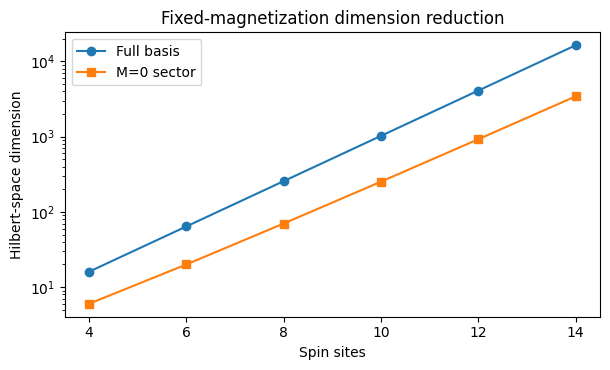

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.semilogy(sizes, full_dimensions, marker="o", label="Full basis")
ax.semilogy(sizes, sector_dimensions, marker="s", label="M=0 sector")
ax.set_xlabel("Spin sites")
ax.set_ylabel("Hilbert-space dimension")
ax.set_title("Fixed-magnetization dimension reduction")
ax.legend()
fig.tight_layout()

In [4]:
sector = xxz_chain_sector(
    n_sites=8,
    magnetization=0,
    coupling=1.0,
    anisotropy=0.7,
    field=0.15,
)
full = xxz_chain_sparse(
    n_sites=8,
    coupling=1.0,
    anisotropy=0.7,
    field=0.15,
)
states = np.asarray(sector.basis.states)
full_block = full[states][:, states]

print("Sector validation")
print(f"  sector shape: {sector.shape}")
print(f"  block matrices agree: {np.allclose(sector.matrix.toarray(), full_block.toarray())}")
print(f"  first basis states: {sector.basis.states[:6]}")

Sector validation
  sector shape: (70, 70)
  block matrices agree: True
  first basis states: (15, 23, 27, 29, 30, 39)


In [5]:
energy, state = ground_state(sector.matrix)
magnetization = site_magnetization_z(state, 8, basis=sector.basis)
correlations = spin_correlation_matrix(
    state,
    8,
    axis="Z",
    basis=sector.basis,
    connected=True,
)
entropy = bipartite_entanglement_entropy(
    state,
    8,
    subsystem=range(4),
    basis=sector.basis,
)

print("Reduced-basis ground state")
print(f"  energy: {energy:.6f}")
print(f"  total magnetization: {magnetization.sum():.6f}")
print(f"  half-chain entropy: {entropy:.6f} bits")

Reduced-basis ground state
  energy: -12.193412
  total magnetization: 0.000000
  half-chain entropy: 0.672396 bits


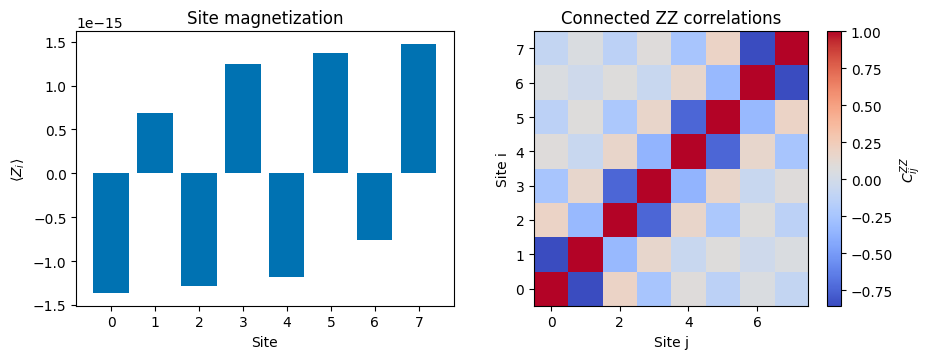

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7))
axes[0].bar(np.arange(8), magnetization, color="#0072B2")
axes[0].set_xlabel("Site")
axes[0].set_ylabel(r"$\langle Z_i\rangle$")
axes[0].set_title("Site magnetization")
image = axes[1].imshow(correlations, cmap="coolwarm", origin="lower")
axes[1].set_xlabel("Site j")
axes[1].set_ylabel("Site i")
axes[1].set_title("Connected ZZ correlations")
fig.colorbar(image, ax=axes[1], label=r"$C_{ij}^{ZZ}$")
fig.tight_layout()